# Programming Tutorial 4 - Convolutional Neural Networks

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```


## Overview

Sections:
- Create an image dataset
- Build and train CNN model
- Advance to training CNN on MNIST dataset
- Visualization of kernels and features

Objectives:
- Learn to build a CNN model
- Learn to break down a CNN model parameters and feature shapes in every layer
- Learn to read and process image data
- Learn to interpret the visualized kernels and intermediate features

## Image Dataset

Convolutional Neural Networks (CNN) are widely used for **image classification** tasks due to their ability to capture spatial features using convolutional layers. In this tutorial, we will implement a basic CNN in PyTorch.

We will start with creating a toy dataset with images that have simple patterns to train the CNN model.

### Numpy Images

`numpy` is a popular data type that we use to hold image data with the pixel values from 0 to 255. A black pixel has the value 0, and a white pixel has the value 255. The shape of the data is `(height, width)` for ***grayscale*** images and `(n_channel, height, width)` for ***color*** images. Today, we will only be using the grayscale images.

To create your own grayscale image using numpy,
1. Create an numpy array with a background color (e.g., `255` for white) and the size `(height, width)`
2. Assign pixels using the coordinate `(y, x)` with other colors (e.g., `0` for black)

Below is a simple example of creating $3 \times 3$ images with assigned patterns. We will use the visualization tool, `matplotlib`, again to observe the these images.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

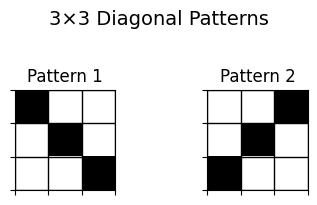

In [ ]:
# Create the first pattern
img_1 = np.full((3, 3), 255, dtype=np.uint8)  # white
img_1[0, 0] = 0                               # black
img_1[1, 1] = 0                               # black
img_1[2, 2] = 0                               # black

# Create the second pattern
img_2 = np.full((3, 3), 255, dtype=np.uint8)  # white
img_2[0, 2] = 0                               # black
img_2[1, 1] = 0                               # black
img_2[2, 0] = 0                               # black

# Plot the images using matplotlit
fig, axes = plt.subplots(1, 2, figsize=(4, 2))     # maks subplots
fig.suptitle("3×3 Diagonal Patterns", fontsize=14) # figure title

for ax, img, title in zip(axes, [img_1, img_2], ["Pattern 1", "Pattern 2"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)

    # Pixel borders for a clearer visualization
    ax.set_xticks(np.arange(-0.5, 3, 1))
    ax.set_yticks(np.arange(-0.5, 3, 1))
    ax.grid(color="black", linewidth=1)

    # Hide tick labels to clean the figure
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    ax.set_title(title)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

### Create Training Dataset

Now, we can use `numpy` to create our own image dataset. For this task, we will create a classification dataset with the above two patterns. Every image will have the size, $7 \times 7$ with a white background. Images with **pattern 1** have the class label `0`, and images with **pattern 2** have the class label `1`.

Starting from the top row, the pattern is printed in each image from left to right. We will generate four rows of data for each pattern. We'll use `r0` as the row and `c0` as the column coordinates of the middle pixel in the $3 \times 3$ pattern.

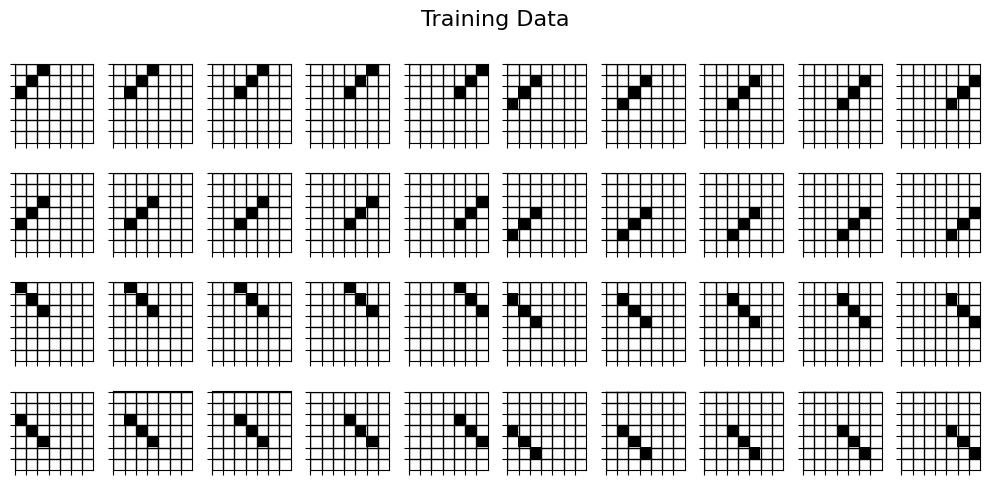

In [ ]:
train_images = []
train_labels = []

# Generate 8 images with diagonal bars
for r0 in [1, 2, 3, 4]:
    for c0 in range(1,6):
        img = np.full((7, 7), 255, dtype=np.uint8)  # white
        img[r0-1, c0+1] = 0                         # black
        img[r0, c0] = 0                             # black
        img[r0+1, c0-1] = 0                         # black
        train_images.append(img)
        train_labels.append(0)

# Generate 8 images with diagonal bars in the other direction
for r0 in [1, 2, 3, 4]:
    for c0 in range(1,6):
        img = np.full((7, 7), 255, dtype=np.uint8)  # white
        img[r0-1, c0-1] = 0                         # black
        img[r0, c0] = 0                             # black
        img[r0+1, c0+1] = 0                         # black
        train_images.append(img)
        train_labels.append(1)

# Visualize in a 2x4 grid with pixel borders
fig, axes = plt.subplots(4, 10, figsize=(10, 5))
fig.suptitle("Training Data", fontsize=16)
for ax, img in zip(axes.ravel(), train_images):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)

    # Pixel borders
    ax.set_xticks(np.arange(-0.5, 6, 1))
    ax.set_yticks(np.arange(-0.5, 6, 1))
    ax.grid(color="black", linewidth=1)

    # Hide tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.tight_layout()
plt.show()

Now that the list of the images and the list of the labels have been created, we can convert the dataset into `torch.tensor` to prepare for training.

In [ ]:
# Convert to torch tensor
X_train = torch.tensor(np.stack(train_images), dtype=torch.float32) / 255.0
X_train = X_train.unsqueeze(1)
y_train = torch.tensor(train_labels)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([40, 1, 7, 7])
y_train shape: torch.Size([40])


### Create Test Set
For the test set, let's generate a group of the same patterns that don't match any examples in the training set.

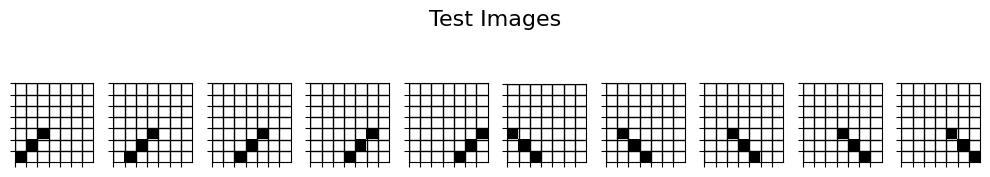

In [ ]:
test_images = []
test_labels = []

# Generate 8 images with diagonal bars
for r0 in [5]:
    for c0 in range(1,6):
        img = np.full((7, 7), 255, dtype=np.uint8)  # white
        img[r0-1, c0+1] = 0                         # black bar
        img[r0, c0] = 0                             # black bar
        img[r0+1, c0-1] = 0                         # black bar
        test_images.append(img)
        test_labels.append(0)

# Generate 8 images with diagonal bars in the other direction
for r0 in [5]:
    for c0 in range(1,6):
        img = np.full((7, 7), 255, dtype=np.uint8)  # white
        img[r0-1, c0-1] = 0                         # black bar
        img[r0, c0] = 0                             # black bar
        img[r0+1, c0+1] = 0                         # black bar
        test_images.append(img)
        test_labels.append(1)

# Visualize in a 2x4 grid with pixel borders
fig, axes = plt.subplots(1, 10, figsize=(10, 2))
fig.suptitle("Test Images", fontsize=16)
for ax, img in zip(axes.ravel(), test_images):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)

    # Pixel borders
    ax.set_xticks(np.arange(-0.5, 6, 1))
    ax.set_yticks(np.arange(-0.5, 6, 1))
    ax.grid(color="black", linewidth=1)

    # Hide tick labels
    ax.set_xticklabels([])
    ax.set_yticklabels([])

plt.tight_layout()
plt.show()

Note that the test set only has the patters at the bottom rows, which does not match the training data.

In [ ]:
# Convert to torch tensor
X_test = torch.tensor(np.stack(test_images), dtype=torch.float32) / 255.0
X_test = X_test.unsqueeze(1)
y_test = torch.tensor(test_labels)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: torch.Size([10, 1, 7, 7])
y_test shape: torch.Size([10])


## CNN Model

The dataset is ready. Now, let's build a CNN model!



### CNN Architecture

Recall that to build a model, we need to use base class `nn.Module` to create the backbone. Review the steps we have used for creating a model:
1. `super().__init__()`: inherit and initialize the parent class `nn.Module`
2. Declare all layers in `__init__()`
3.  Define forward pass in `forward(self, x)`


The basic model layers we use in a CNN are:
- [`nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [`nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

An example of a CNN model architecture is [here](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html#define-a-convolutional-neural-network). Tips for building a CNN model are:
- The input channel size should match your data. For instance, a greyscale image has 1 channel, and a color image typically has 3 channels (e.g., RGB).
- The size of `out_channels` should match the size of `in_channels` of the next layer.



Today, we will design a model with two convolution layers followed by a max pooling layer each, and the features are flattened and connected to a linear layer before the output.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(SimpleCNN, self).__init__() # make sure that the parent class (nn.Module) is properly initialized

        self.n_channels = n_channels
        self.n_classes = n_classes

        # Declare all layers used in this model
        self.conv1 = nn.Conv2d(in_channels=n_channels, out_channels=4, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=4, out_channels=4, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(4, 8)
        self.fc2 = nn.Linear(8, n_classes)

    def forward(self, x):
        # First convolution and pooling pass
        x = self.conv1(x)
        x = torch.sigmoid(x)
        x = self.pool1(x)

        # Second convolution and pooling pass
        x = self.conv2(x)
        x = torch.sigmoid(x)
        x = self.pool2(x)

        # Flatten the features (the first dimention is batch size)
        x = x.view(-1, 4)

        # Fully connected layers
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x

In [75]:
xb = torch.rand((1,3,64,64))
yb = torch.tensor([3])
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=9, padding=0, stride=1)
bn1 = nn.BatchNorm2d(num_features=6)
conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=9)
bn2 = nn.BatchNorm2d(num_features=12)
conv3 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=9)
bn3 = nn.BatchNorm2d(num_features=24)
conv4 = nn.Conv2d(in_channels=24, out_channels=48, kernel_size=9)
bn4 = nn.BatchNorm2d(num_features=48)
conv5 = nn.Conv2d(in_channels=48, out_channels=48*2, kernel_size=9)
bn5 = nn.BatchNorm2d(num_features=48*2)
conv6 = nn.Conv2d(in_channels=48*2, out_channels=48*4, kernel_size=9)
bn6 = nn.BatchNorm2d(num_features=48*4)
conv7 = nn.Conv2d(in_channels=48*4, out_channels=48*8, kernel_size=9)
bn7 = nn.BatchNorm2d(num_features=48*8)

x = conv1(xb)
x = bn1(x)
x = conv2(x)
x = bn2(x)
x = conv3(x)
x = bn3(x)
x = conv4(x)
x = bn4(x)
x = conv5(x)
x = bn5(x)
x = conv6(x)
x = bn6(x)
x = conv7(x)
# x = bn7(x)
print(x.shape)
print(xb.flatten().shape[0])

torch.Size([1, 384, 8, 8])
12288


In [76]:
4*(10440362 + 534468)

43899320

For the `forward` function, an alternative coding style is to pass on data through multiple layers in one line. For instance,
```
x = self.pool1(torch.sigmoid(self.conv1(x)))
x = self.pool2(torch.sigmoid(self.conv2(x)))
x = x.view(-1, 4)
x = self.fc2(torch.sigmoid(self.fc1(x)))
```
We'll be using this technique in the following sections to construct deeper models.

### Intermediate Layers

For each layer, calculate the size of the features:

**[Convolution Layer]**

Assume the size of the input features is $(C_1, L_1, L_1)$ and the size of the output features is $(C_2, L_2, L_2)$. The padding size of the layer is $p$, the kernel size is $k$, the stride is $s$. Then we have:

- $L_2 = \frac{L_1 - k + 2p}{s} + 1$

- $C_2$ is dynamic, assigned in the architecture.

**[Pooling Layer]**

Assume the size of the input features is $(C_1, L_1, L_1)$ and the size of the output features is $(C_2, L_2, L_2)$. The stride is $s$. Then we have:

- $L_2 = \frac{L_1}{s}$

- $C_2 = C_1$


**[Linear Layers]**

When the convolutional features are flattened, the linear layer will receive the input with the size of the number of features:

- $Flattened\_size = C_n \times L_n \times L_n$

**[Practice]**

With the above formulas, we can calculate the following feature sizes:
- Input image size: $(1, 7, 7)$
- Layer `self.conv1`: $k = 3$, $p = 1$, $s = 1$
- Feature size after `self.conv1`: $(C_{conv1}, 7 + 2 - 2, 7 + 2 - 2) = (4, 7, 7)$
- Layer `self.pool1`: $s = 2$
- Feature size after `self.pool1`: $(C_{conv1}, 7 / 2,  7 / 2) = (4, 3, 3)$
- Layer `self.conv1`: $k = 3$, $p = 1$, $s = 1$
- Feature size after: `self.conv2`: $(C_{conv2}, 3 + 2 - 2, 3 + 2 - 2) = (4, 3, 3)$
- Layer `self.pool2`: $s = 2$
- Feature size after: `self.pool2`: $(C_{conv2}, 3/2, 3/2) = (4, 1, 1)$
- Flattened size for the input of `self.fc1`: $ 4 \times 1 \times 1 = 4$


Now, let's use `torchsummary` to see the overview of our CNN architecture. Our input images will be `(1, 7, 7)` from the dataset.

In [ ]:
from torchsummary import summary

model = SimpleCNN(n_channels=1, n_classes=2)
summary(model, input_size=(1, 7, 7))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1              [-1, 4, 7, 7]              40
         MaxPool2d-2              [-1, 4, 3, 3]               0
            Conv2d-3              [-1, 4, 3, 3]             148
         MaxPool2d-4              [-1, 4, 1, 1]               0
            Linear-5                    [-1, 8]              40
            Linear-6                    [-1, 2]              18
Total params: 246
Trainable params: 246
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


### Model Training

For training, we will use the [cross-entropy loss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) and [SGD optimizer](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#torch.optim.SGD). To evaluate the model performance, we will implement accuracy.

In [ ]:
model = SimpleCNN(n_channels=1, n_classes=2)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 30000
model.train()
for epoch in range(1, epochs + 1):
    optimizer.zero_grad()

    logits = model(X_train)
    loss = criterion(logits, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0 or epoch == 1:
        preds = logits.argmax(dim=1)
        acc = (preds == y_train).float().mean().item()
        print(f"Epoch {epoch:3d} | loss={loss.item():.4f} | acc={acc:.3f}")

Epoch   1 | loss=0.8158 | acc=0.500
Epoch 1000 | loss=0.6931 | acc=0.550
Epoch 2000 | loss=0.6930 | acc=0.600
Epoch 3000 | loss=0.6929 | acc=0.750
Epoch 4000 | loss=0.6927 | acc=0.900
Epoch 5000 | loss=0.6921 | acc=0.950
Epoch 6000 | loss=0.6904 | acc=0.925
Epoch 7000 | loss=0.6723 | acc=0.975
Epoch 8000 | loss=0.0526 | acc=1.000
Epoch 9000 | loss=0.0102 | acc=1.000
Epoch 10000 | loss=0.0051 | acc=1.000
Epoch 11000 | loss=0.0033 | acc=1.000
Epoch 12000 | loss=0.0024 | acc=1.000
Epoch 13000 | loss=0.0019 | acc=1.000
Epoch 14000 | loss=0.0015 | acc=1.000
Epoch 15000 | loss=0.0013 | acc=1.000
Epoch 16000 | loss=0.0011 | acc=1.000
Epoch 17000 | loss=0.0010 | acc=1.000
Epoch 18000 | loss=0.0009 | acc=1.000
Epoch 19000 | loss=0.0008 | acc=1.000
Epoch 20000 | loss=0.0007 | acc=1.000
Epoch 21000 | loss=0.0006 | acc=1.000
Epoch 22000 | loss=0.0006 | acc=1.000
Epoch 23000 | loss=0.0006 | acc=1.000
Epoch 24000 | loss=0.0005 | acc=1.000
Epoch 25000 | loss=0.0005 | acc=1.000
Epoch 26000 | loss=0.00

### Evaluation on Test Set
The model is now performing very well on the training set. Let's use the model to predict classes on the test set.

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(X_test)
    preds = logits.argmax(dim=1)

Visualize the ground truth labels and predictions to visualize model performance.

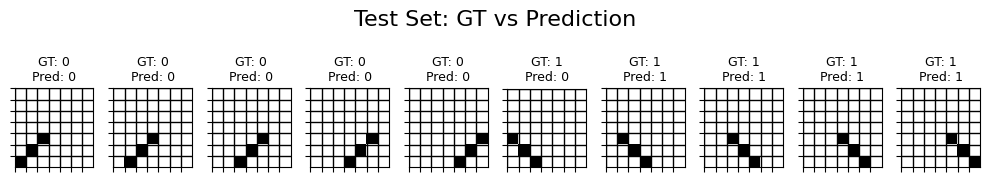

In [ ]:
fig, axes = plt.subplots(1, 10, figsize=(10, 2))
fig.suptitle("Test Set: GT vs Prediction", fontsize=16)

for ax, img, gt, pred in zip(axes.ravel(), test_images, y_test, preds):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)

    # Pixel borders
    ax.set_xticks(np.arange(-0.5, 6, 1))
    ax.set_yticks(np.arange(-0.5, 6, 1))
    ax.grid(color="black", linewidth=1)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_title(f"GT: {int(gt)}\nPred: {int(pred)}", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Training a CNN Model Using MNIST

Now that we have experimented with a CNN using simple, contrived patterns, we will move on to a real-world benchmark dataset: MNIST. MNIST contains grayscale images of handwritten digits (0–9) and is a classic starting point for learning about image classification with neural networks.

### MNIST Dataset

**[[Download data here](https://o365coloradoedu-my.sharepoint.com/:u:/g/personal/yuts1923_colorado_edu/IQCMlg0VSFowQIo5FZo4YQKTAYdzEUcXQmYGfnjFGaxmLKA?e=nA8hwa)]: mnist_1000.npz**


We'll be using a subset of the MNIST dataset with the digits `0` and `1`. You will need to upload this dataset to your Google Drive. To connect this Colab script to your Google Drive, run the following cell.

#### Read Data From Google Drive


When you run this cell, a window will pop out for you to select the access to your files. Failing to select Google Drive access will lead to an error of connection.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


When your Google Drive is connected, point the script to where you saved the data (changing this line to your path is required here):

In [ ]:
dataset_path = '/content/drive/MyDrive/Courses/CSCI 5922/CSCI 5922 SP26/Demo' # change to your path

In [ ]:
import numpy as np
import torch

path = f"{dataset_path}/mnist_1000.npz"
data = np.load(path)

images = data["images"]   # (1000, 28, 28) uint8
labels = data["labels"]   # (1000,) uint8

print("Loaded:", images.shape, labels.shape)


Loaded: (1000, 28, 28) (1000,)


#### Data Preprocessing

In [ ]:
# Split data into train/test
np.random.seed(42)
perm = np.random.permutation(len(images)) # Get random indices
n_test = int(len(images) * 0.2)           # test ratio = 0.2

test_idx = perm[:n_test]
train_idx = perm[n_test:]
X_train_np, y_train_np = images[train_idx], labels[train_idx]
X_test_np,  y_test_np  = images[test_idx],  labels[test_idx]

print("Train:", X_train_np.shape, y_train_np.shape)
print("Test: ", X_test_np.shape, y_test_np.shape)

Train: (800, 28, 28) (800,)
Test:  (200, 28, 28) (200,)


**[Image Normalization]**

In this tutorial, we scale MNIST pixel intensities from `[0,255]` to `[0,1]` using $x/255$. This is safe because it applies the same scaling to every pixel, preserving the image’s relative brightness patterns while shrinking values into `[0,1]` for more stable training.

This is a common practice in vision data pre-processing as it keeps the step simple. In practice, it is also common to center the data around 0 by subtracting a mean.

In [ ]:
# Normalize
X_train = torch.tensor(X_train_np, dtype=torch.float32) / 255.0
X_test  = torch.tensor(X_test_np,  dtype=torch.float32) / 255.0

Finally, prepare the data for the torch model:

In [ ]:
# Reshape
X_train = X_train.unsqueeze(1)  # (N, 1, 28, 28)
X_test  = X_test.unsqueeze(1)   # (N, 1, 28, 28)

y_train = torch.tensor(y_train_np, dtype=torch.long)
y_test  = torch.tensor(y_test_np,  dtype=torch.long)

print("X_train:", X_train.shape, X_train.dtype)
print("y_train:", y_train.shape, y_train.dtype)
print("X_test: ", X_test.shape,  X_test.dtype)
print("y_test: ", y_test.shape,  y_test.dtype)

### CNN Model Training

Similar to the first CNN model we built, we'll use a model with the same structure of convolution, max pooling, and linear layers. For the MNIST task, we will increase the number of channels in each layer to increase the complexity.

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(SimpleCNN, self).__init__() # make sure that the parent class (nn.Module) is properly initialized

        self.n_channels = n_channels
        self.n_classes = n_classes

        # Declare all layers used in this model
        self.conv1 = nn.Conv2d(in_channels=n_channels, out_channels=16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(16*7*7, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        # Convolution and pooling passes
        x = self.conv1(x)
        x = torch.sigmoid(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.sigmoid(x)
        x = self.pool2(x)

        x = x.view(-1, 16*7*7)             # flatten
        x = torch.sigmoid(self.fc1(x)) # linear
        x = self.fc2(x)
        return x

In [ ]:
model = SimpleCNN(n_channels=1, n_classes=2)
summary(model, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             160
         MaxPool2d-2           [-1, 16, 14, 14]               0
            Conv2d-3           [-1, 16, 14, 14]           2,320
         MaxPool2d-4             [-1, 16, 7, 7]               0
            Linear-5                   [-1, 32]          25,120
            Linear-6                    [-1, 2]              66
Total params: 27,666
Trainable params: 27,666
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.11
Estimated Total Size (MB): 0.26
----------------------------------------------------------------


In [ ]:
model = SimpleCNN(n_channels=1, n_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 500
for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    logits = model(X_train)
    loss = criterion(logits, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 1:
        with torch.no_grad():
            train_acc = (logits.argmax(dim=1) == y_train).float().mean().item()
            test_logits = model(X_test)
            test_acc = (test_logits.argmax(dim=1) == y_test).float().mean().item()
        print(f"Epoch {epoch:3d} | loss={loss.item():.4f} | train_acc={train_acc:.3f} | test_acc={test_acc:.3f}")

Epoch   1 | loss=0.7713 | train_acc=0.502 | test_acc=0.490
Epoch  50 | loss=0.6929 | train_acc=0.502 | test_acc=0.490
Epoch 100 | loss=0.6926 | train_acc=0.502 | test_acc=0.490
Epoch 150 | loss=0.6921 | train_acc=0.502 | test_acc=0.490
Epoch 200 | loss=0.6916 | train_acc=0.502 | test_acc=0.490
Epoch 250 | loss=0.6909 | train_acc=0.502 | test_acc=0.490
Epoch 300 | loss=0.6899 | train_acc=0.502 | test_acc=0.490
Epoch 350 | loss=0.6883 | train_acc=0.502 | test_acc=0.490
Epoch 400 | loss=0.6859 | train_acc=0.909 | test_acc=0.915
Epoch 450 | loss=0.6816 | train_acc=0.988 | test_acc=0.990
Epoch 500 | loss=0.6731 | train_acc=0.998 | test_acc=1.000


The model has reached very high accuracies for both train and test sets. Below, we randomly pick a few examples from the test set for the model to make predictions:

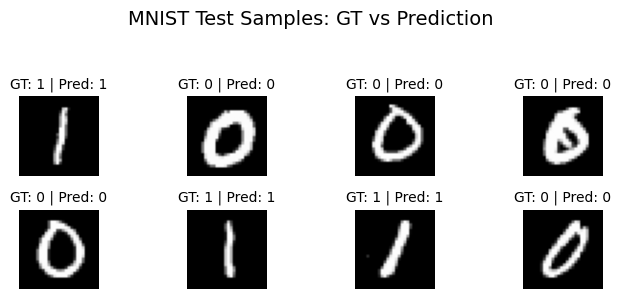

In [ ]:
# Pick random test indices
num_samples = 8
idxs = np.random.choice(len(X_test), size=num_samples, replace=False)

model.eval()
with torch.no_grad():
    logits = model(X_test[idxs].to(next(model.parameters()).device))
    preds = logits.argmax(dim=1)

# Plot results
fig, axes = plt.subplots(2, 4, figsize=(7, 3))
fig.suptitle("MNIST Test Samples: GT vs Prediction", fontsize=14)

for ax, idx, pred in zip(axes.ravel(), idxs, preds):
    img = X_test[idx].squeeze(0).numpy()
    gt = y_test[idx].item()

    ax.imshow(img, cmap="gray")
    ax.set_title(f"GT: {gt} | Pred: {pred.item()}", fontsize=10)
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


## CNN Visualizations *(Coding Not Required)*

In the lecture, we saw several examples of visualizing convolutional kernels and intermediate feature maps inside a CNN. These visualizations are useful because they give us an interpretable window into what the network is learning.

In this section, we will visualize and observe the CNN trained in the previous section. You do not need to write code for these visualizations. The goal is simply to understand what each visualization represents and how to interpret what you see.



### Kernels

A **kernel** is the matrix of learnable weights inside one channel of a convolutional layer. For example, a $3 \times 3$ kernel slides across the image and computes a weighted sum at each location. During training, the CNN updates these weights so that each kernel becomes sensitive to certain patterns.

When we visualize kernels, we are essentially asking:

> What patterns does this CNN look for?

We can get the values of kernels using `layer.weight`:

In [ ]:
print('Conv1 weights shape:', model.conv1.weight.detach().shape)
print('Conv2 weights shape:', model.conv2.weight.detach().shape)

Conv1 weights shape: torch.Size([16, 1, 3, 3])
Conv2 weights shape: torch.Size([16, 16, 3, 3])


From the shapes, we can see that `conv2` has 16 input and 16 output channels. We will visualize the mean values of kernels over the second dimension:

In [ ]:
W_1 = model.conv1.weight.detach().squeeze(1)  # reshape to [16, 3, 3]
W_2 = model.conv2.weight.detach().mean(dim=1) # reshape to [16, 3, 3]

Now, let's plot the $3 \times 3$ kernels:

Learned conv1 kernels (3 x 3):


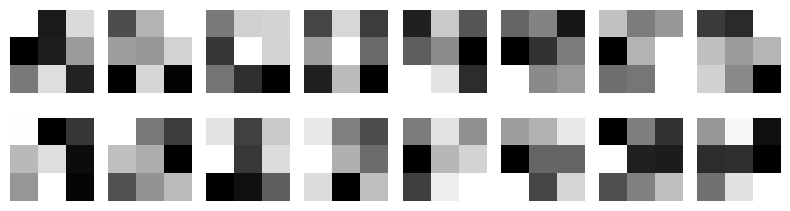


Learned conv2 kernels (3 x 3):


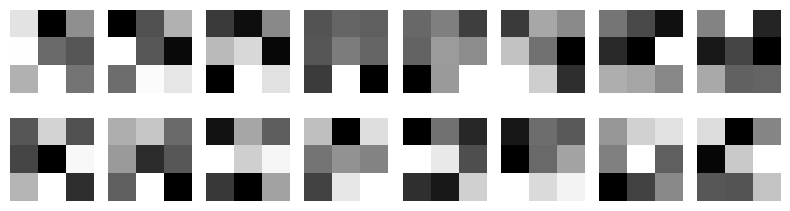

In [ ]:
# Visualize conv1 weights
print('Learned conv1 kernels (3 x 3):')
fig, axes = plt.subplots(2, 8, figsize=(8, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(W_1[i], cmap="gray")
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# Visualize conv2 weights
print('\nLearned conv2 kernels (3 x 3):')
fig, axes = plt.subplots(2, 8, figsize=(8, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(W_2[i], cmap="gray")
    ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

### Intermediate Features

While kernels show what the model is looking for, intermediate feature maps show:

> Where the model is detecting those patterns in a specific input image.

Each convolutional layer outputs a stack of feature maps (also called activation maps). Each feature map is a 2D grid where:

- brighter values indicate stronger activation
- darker values indicate weaker activation

In [ ]:
@torch.no_grad()
def get_features(model, x):
    feats = {}
    feats["input"] = x
    feats["conv1"] = torch.sigmoid(model.conv1(x))
    feats["pool1"] = model.pool1(feats["conv1"])
    feats["conv2"] = torch.sigmoid(model.conv2(feats["pool1"]))
    feats["pool2"] = model.pool2(feats["conv2"])
    return feats


def show_feature_grid(feat, title, max_ch=16):
    if feat.dim() == 4:
        feat = feat[0]  # (C, H, W)

    C, H, W = feat.shape
    Cshow = min(C, max_ch)

    cols = min(8, Cshow)
    rows = (Cshow + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    fig.suptitle(f"{title}  (C={C}, H={H}, W={W})", fontsize=14)

    axes = np.array(axes).reshape(-1)
    for i in range(rows * cols):
        ax = axes[i]
        ax.axis("off")
        if i < Cshow:
            ax.imshow(feat[i].detach().cpu().numpy(), cmap="gray")

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()


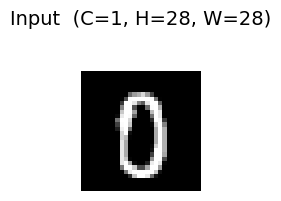

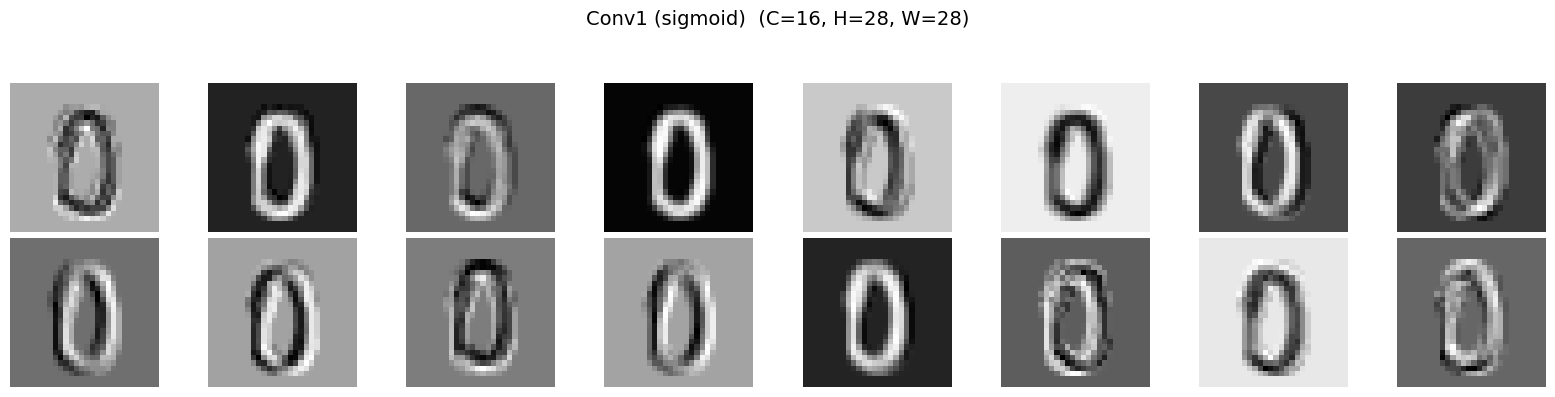

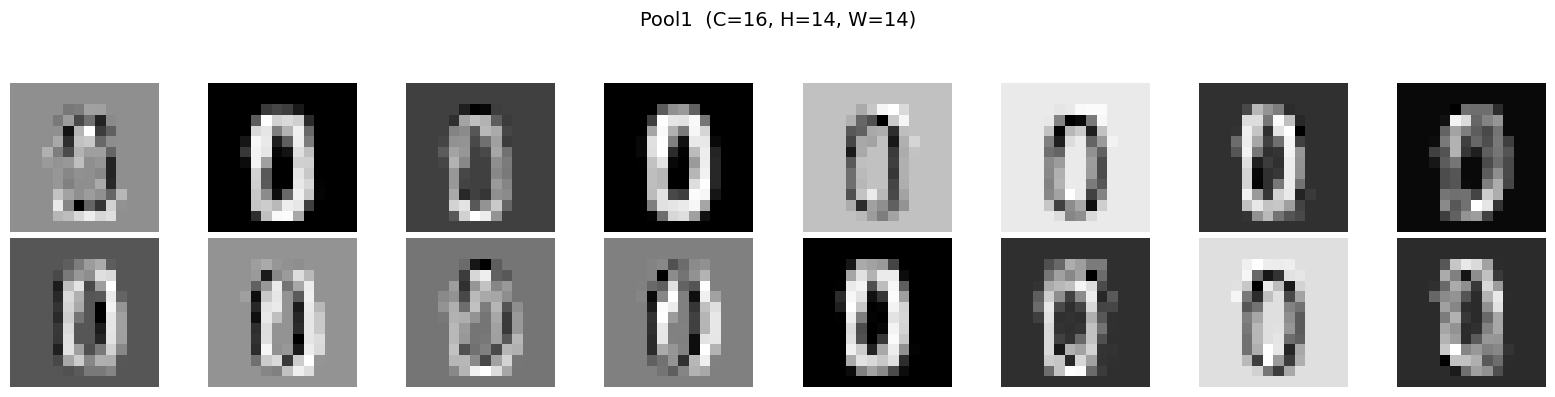

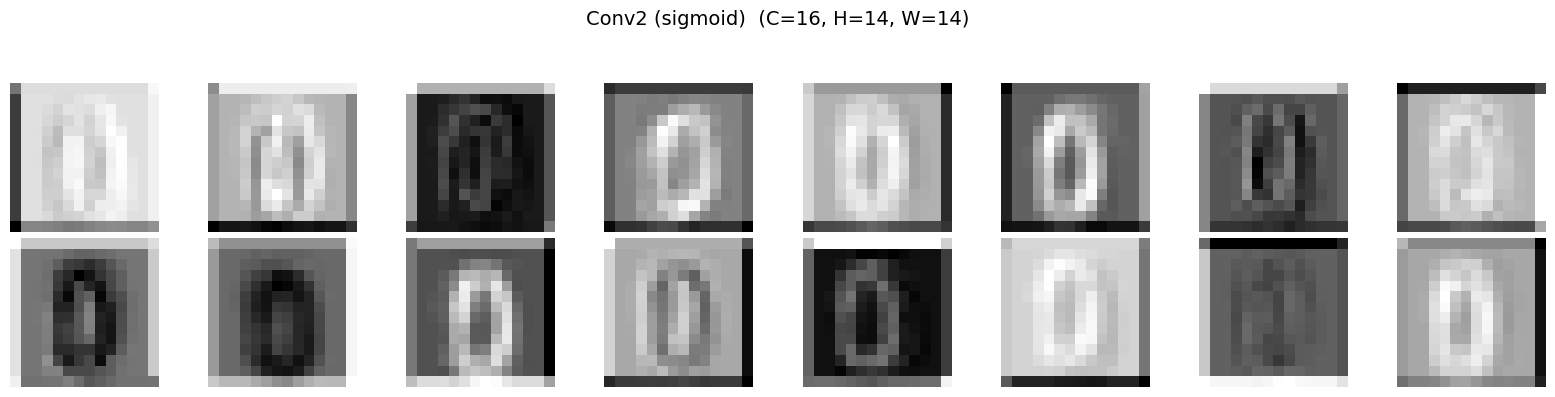

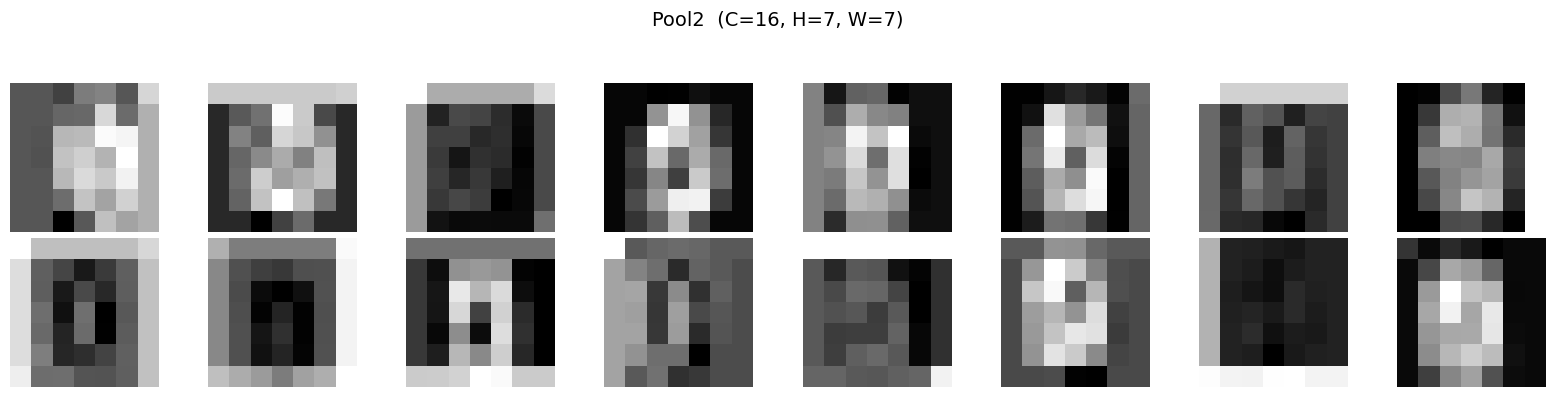

In [ ]:
idx = 0 # pick your index
x = X_test[idx:idx+1].to(next(model.parameters()).device)  # (1,1,28,28)

feats = get_features(model, x)
show_feature_grid(feats["input"], "Input", max_ch=1)
show_feature_grid(feats["conv1"], "Conv1 (sigmoid)", max_ch=16)
show_feature_grid(feats["pool1"], "Pool1", max_ch=16)
show_feature_grid(feats["conv2"], "Conv2 (sigmoid)", max_ch=16)
show_feature_grid(feats["pool2"], "Pool2", max_ch=16)


## Review

Today, we learned how to build a CNN model using convolution and max pooling layers. The CNN architecture allowed us to automatically learn useful visual features from images. We started by experimenting with small, controlled synthetic datasets (e.g., simple bars and diagonal patterns) to understand how convolution, pooling, and flattening work, and how a model can learn to separate different classes.

After gaining intuition from these toy examples, we moved on to a real-world dataset, MNIST, and trained a larger CNN to classify handwritten digits.


For next steps, try the following:
- Create your own patterns and datasets to train a CNN model
- Create your own CNN model with three convolution layers
- In the `torchsummary` prints, there are number of parameters for every layer. Using what you learned in the lecture, prove these numbers correct by hand-calculation.

For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley